In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Structure

In [38]:
df = pd.read_hdf("_electrode_data_with_energies.h5")
mask = np.ones((df.shape[0]),dtype=bool)
df['working_ion'] = df['working_ion'].astype(str)
df

,charge_id,discharge_id,working_ion,charge_material_id,charge_structure,charge_energy_per_atom,charge_origins,charge_formula,discharge_material_id,discharge_structure,...,Na_discharge_init_energy_per_atom,Na_discharge_init_forces,Na_discharge_relaxed_structure,Na_discharge_relaxed_energy_per_atom,Na_discharge_relaxed_forces,charge_init_energy_per_atom,charge_init_forces,charge_relaxed_structure,charge_relaxed_energy_per_atom,charge_relaxed_forces
0,mp-1022721,mp-1183161,Al,mp-1022721,"[[0. 0. 0.] Al, [1.4987545 1.4987545 1.4987545...",-8.957870,[name='structure' task_id=MPID(mp-1795466) las...,Al1 Cu1,mp-1183161,"[[0. 1.9620755 1.9620755] Al, [1.962075...",...,-1.955683,"[[7.856378e-08, -1.2784733e-07, 8.597702e-08],...","[[0.00428237 2.01321889 2.01392374] Al, [ 2.49...",-2.270267,"[[1.5686252e-05, -0.00020659436, -0.0002688238...",-3.892441,"[[-1.5571946e-08, -1.1264812e-08, -2.1659915e-...",[[ 6.52696259e-10 -8.91056995e-10 1.61326789e...,-3.894709,"[[4.944921e-07, -7.8688025e-09, -3.121844e-07]..."
1,mp-1055908,mp-1104165,Al,mp-1055908,[[0. 0. 0.] Mn],-14.313609,[name='structure' task_id=MPID(mp-2047765) las...,Mn1,mp-1104165,"[[0. 0. 0.] Mn, [ 1.44467232 -3.70208257 -2.33...",...,-0.613377,"[[1.4644256e-07, 1.6532768e-07, 6.904667e-07],...",[[2.45784295e-05 7.29098984e-06 1.06321370e-05...,-1.345393,"[[-5.2681302e-05, -1.833547e-05, -3.3855977e-0...",-8.869469,"[[0.0, 0.0, 0.0]]",[[0. 0. 0.] Mn],-8.879036,"[[0.0, 0.0, 0.0]]"
2,mp-129,mp-550,Al,mp-129,[[0. 0. 0.] Mo],-26.071979,[name='structure' task_id=MPID(mp-1949792) las...,Mo1,mp-550,"[[ 2.09226601 1.63807152 -0.52677005] Al, [-0...",...,-0.792050,"[[0.42265126, 0.5156991, -0.33733216], [0.6601...","[[ 2.33984977 1.90991056 -0.69759004] Na, [-0...",-1.435296,"[[-0.21827751, -0.19684413, 0.088205166], [-0....",-10.920197,"[[0.0, 0.0, 0.0]]",[[0. 0. 0.] Mo],-10.920696,"[[0.0, 0.0, 0.0]]"
3,mp-2647037,mp-1648,Al,mp-2647037,[[0. 0. 0.] Re],-52.092303,[name='structure' task_id=MPID(mp-2647037) las...,Re1,mp-1648,"[[ 2.08544575 1.62876969 -0.52020113] Al, [-0...",...,-0.894939,"[[0.2866568, 0.43440083, -0.32723066], [0.5185...","[[ 2.40057667 1.99933609 -0.75704481] Na, [-0...",-1.670668,"[[-0.11619051, -0.1796076, 0.123975635], [-0.2...",-12.067584,"[[0.0, 0.0, 0.0]]",[[0. 0. 0.] Re],-12.067584,"[[0.0, 0.0, 0.0]]"
4,mp-16722,mp-1229052,Al,mp-16722,"[[ 5.848228 4.13532172 10.1294277 ] Al, [5....",-7.502557,[name='structure' task_id=MPID(mp-2034355) las...,Al40 V4,mp-1229052,"[[12.52262808 8.97357443 8.97358668] Al, [ 8...",...,-4.258263,"[[0.18276893, -0.18267019, -0.18281667], [-0.1...","[[12.73622205 8.98579227 8.98578228] Al, [ 8...",-4.265461,"[[-6.5659275e-05, 5.5976838e-05, 3.6606663e-05...",-4.312361,"[[-1.7062877e-07, -1.9140808e-07, 5.210804e-07...","[[ 5.89632374 4.16933035 10.21273138] Al, [5....",-4.315773,"[[-1.1382016e-06, -2.6638227e-07, 1.0836169e-0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6842,mp-867653,mp-1178025,Li,mp-867653,"[[2.846898 3.24925348 1.95432155] Co, [1.456...",-6.370493,[name='structure' task_id=MPID(mp-1776699) las...,Co6 Te2 O16,mp-1178025,"[[1.69711509 2.94928999 0.90939975] Li, [-0.00...",...,-5.358135,"[[0.038395006, -0.30009717, 0.5110264], [0.053...","[[1.76105163 3.04410276 1.0509283 ] Na, [0.046...",-5.482992,"[[-0.022298476, -0.013854115, -0.012261095], [...",-5.713751,"[[0.044745643, 0.10324692, 0.018354492], [-0.1...","[[2.84521755 3.2410457 1.95233076] Co, [1.446...",-5.714402,"[[-0.00067627436, 0.027778009, 0.0026370422], ..."
6843,mp-893207,mp-884044,Li,mp-893207,"[[9.04013353 1.0352169 1.71203433] Li, [ 0.46...",-7.692820,[name='structure' task_id=MPID(mp-893207) last...,Li10 Mn12 B12 O36,mp-884044,"[[1.25226279 7.82743734 2.15135079] Li, [-0.69...",...,-7.006559,"[[-0.32356036, -0.77602637, -0.21886879], [-0....","[[0.82121854 7.7816567 2.00468155] Li, [-0.95...",-7.270885,"[[0.013262882, 0.02460796, -0.009248399], [0.0...",-7.046790,"[[-1.5806901, 3.584482, 2.2290149], [0.01

In [39]:
df.columns

Index(['charge_id', 'discharge_id', 'working_ion', 'charge_material_id',
       'charge_structure', 'charge_energy_per_atom', 'charge_origins',
       'charge_formula', 'discharge_material_id', 'discharge_structure',
       'discharge_energy_per_atom', 'discharge_origins', 'discharge_formula',
       'Li_discharge_structure', 'Li_discharge_formula',
       'Na_discharge_structure', 'Na_discharge_formula',
       'Li_discharge_init_energy_per_atom', 'Li_discharge_init_forces',
       'Li_discharge_relaxed_structure',
       'Li_discharge_relaxed_energy_per_atom', 'Li_discharge_relaxed_forces',
       'Na_discharge_init_energy_per_atom', 'Na_discharge_init_forces',
       'Na_discharge_relaxed_structure',
       'Na_discharge_relaxed_energy_per_atom', 'Na_discharge_relaxed_forces',
       'charge_init_energy_per_atom', 'charge_init_forces',
       'charge_relaxed_structure', 'charge_relaxed_energy_per_atom',
       'charge_relaxed_forces'],
      dtype='object')

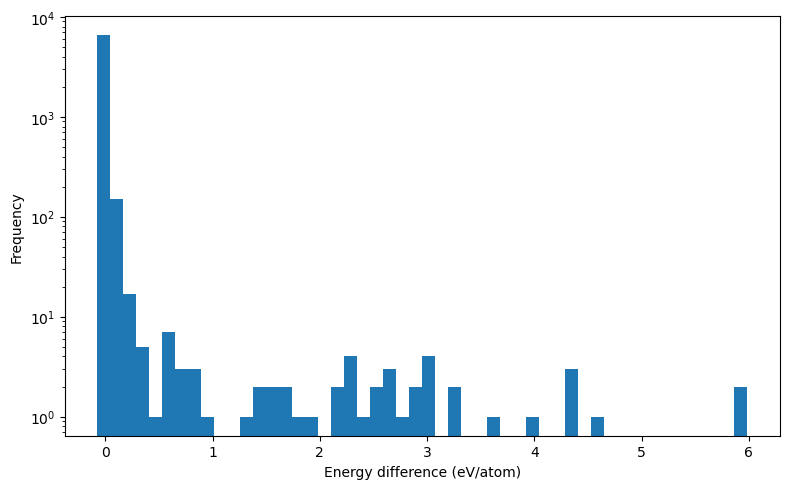

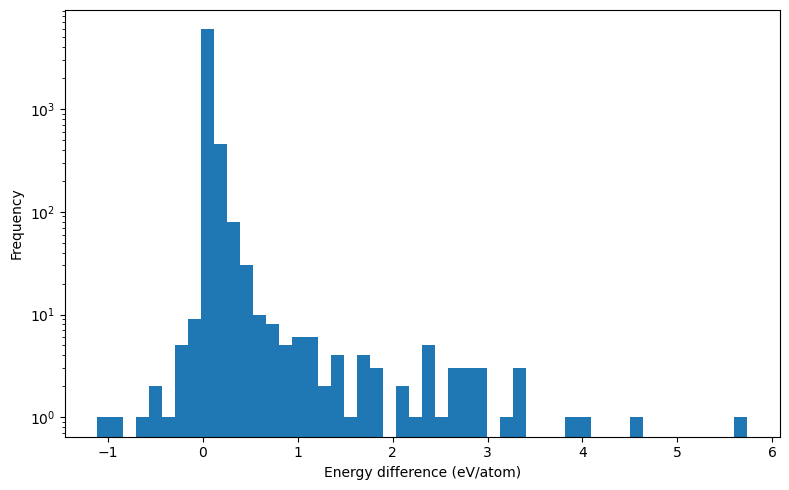

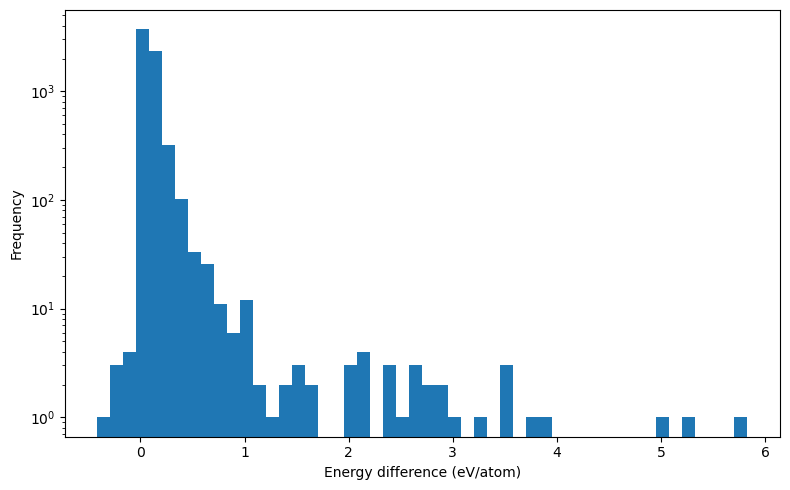

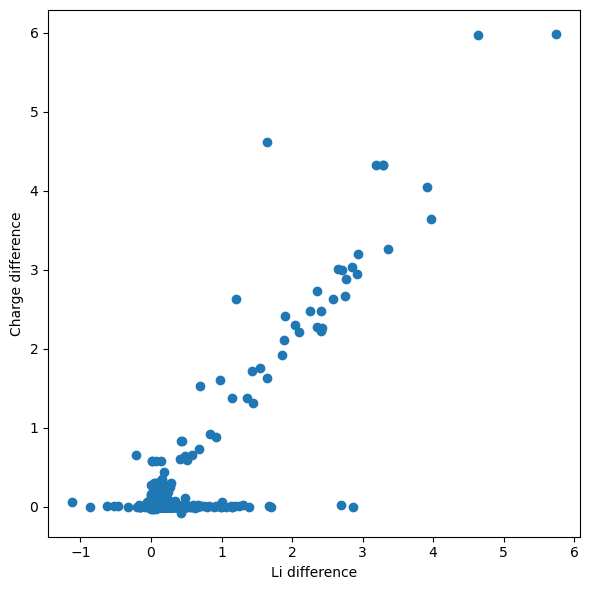

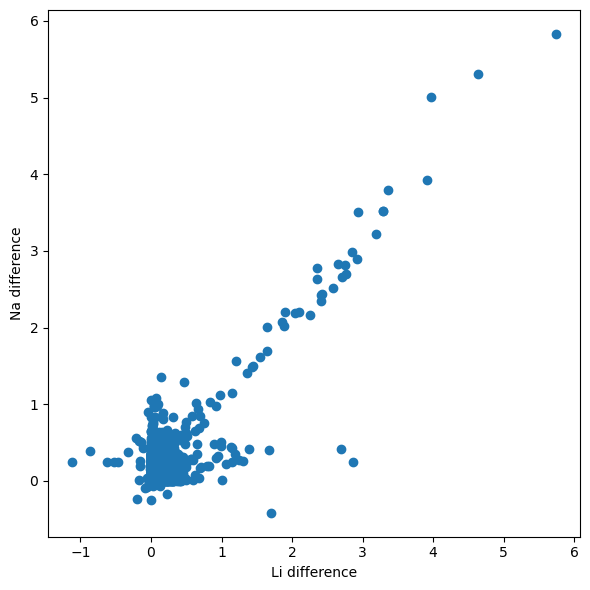

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df['charge_init_energy_per_atom'] - df['charge_relaxed_energy_per_atom'],bins=50)
plt.yscale('log')
# plt.xlim(0,2)
plt.xlabel("Energy difference (eV/atom)")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig("energy_diff_hist_charg.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['Li_discharge_init_energy_per_atom'] - df['Li_discharge_relaxed_energy_per_atom'],bins=50)
plt.yscale('log')
# plt.xlim(0,2)
plt.xlabel("Energy difference (eV/atom)")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig("energy_diff_hist_Li.png", dpi=300)

plt.figure(figsize=(8,5))
plt.hist(df['Na_discharge_init_energy_per_atom'] - df['Na_discharge_relaxed_energy_per_atom'],bins=50)
plt.yscale('log')
# plt.xlim(0,2)
plt.xlabel("Energy difference (eV/atom)")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig("energy_diff_hist_Na.png", dpi=300)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df['Li_discharge_init_energy_per_atom'] - df['Li_discharge_relaxed_energy_per_atom'],
            df['charge_init_energy_per_atom'] - df['charge_relaxed_energy_per_atom'])
# plt.yscale('log')
plt.xlabel("Li difference")
plt.ylabel("Charge difference")
plt.tight_layout()
# plt.savefig("energy_diff_li_charg_scatter.png", dpi=300)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df['Li_discharge_init_energy_per_atom'] - df['Li_discharge_relaxed_energy_per_atom'],
            df['Na_discharge_init_energy_per_atom'] - df['Na_discharge_relaxed_energy_per_atom'])
# plt.yscale('log')
plt.xlabel("Li difference")
plt.ylabel("Na difference")
plt.tight_layout()
# plt.savefig("energy_diff_li_na_scatter.png", dpi=300)
plt.show()

In [41]:
li_diff = df['Li_discharge_init_energy_per_atom'] - df['Li_discharge_relaxed_energy_per_atom']
na_diff = df['Na_discharge_init_energy_per_atom'] - df['Na_discharge_relaxed_energy_per_atom']

mask *= ~li_diff.isna()
mask *= ~na_diff.isna()
mask *= ~df['charge_relaxed_energy_per_atom'].isna()

mask *= li_diff>0
mask *= na_diff>0

mask *= li_diff<0.5
mask *= na_diff<0.75

mask[df[df['charge_formula']=='Na1'].index[0]] = False
# mask[df[df['charge_formula']=='Li1'].index[0]] = False

df=df[mask]
df

,charge_id,discharge_id,working_ion,charge_material_id,charge_structure,charge_energy_per_atom,charge_origins,charge_formula,discharge_material_id,discharge_structure,...,Na_discharge_init_energy_per_atom,Na_discharge_init_forces,Na_discharge_relaxed_structure,Na_discharge_relaxed_energy_per_atom,Na_discharge_relaxed_forces,charge_init_energy_per_atom,charge_init_forces,charge_relaxed_structure,charge_relaxed_energy_per_atom,charge_relaxed_forces
0,mp-1022721,mp-1183161,Al,mp-1022721,"[[0. 0. 0.] Al, [1.4987545 1.4987545 1.4987545...",-8.957870,[name='structure' task_id=MPID(mp-1795466) las...,Al1 Cu1,mp-1183161,"[[0. 1.9620755 1.9620755] Al, [1.962075...",...,-1.955683,"[[7.856378e-08, -1.2784733e-07, 8.597702e-08],...","[[0.00428237 2.01321889 2.01392374] Al, [ 2.49...",-2.270267,"[[1.5686252e-05, -0.00020659436, -0.0002688238...",-3.892441,"[[-1.5571946e-08, -1.1264812e-08, -2.1659915e-...",[[ 6.52696259e-10 -8.91056995e-10 1.61326789e...,-3.894709,"[[4.944921e-07, -7.8688025e-09, -3.121844e-07]..."
1,mp-1055908,mp-1104165,Al,mp-1055908,[[0. 0. 0.] Mn],-14.313609,[name='structure' task_id=MPID(mp-2047765) las...,Mn1,mp-1104165,"[[0. 0. 0.] Mn, [ 1.44467232 -3.70208257 -2.33...",...,-0.613377,"[[1.4644256e-07, 1.6532768e-07, 6.904667e-07],...",[[2.45784295e-05 7.29098984e-06 1.06321370e-05...,-1.345393,"[[-5.2681302e-05, -1.833547e-05, -3.3855977e-0...",-8.869469,"[[0.0, 0.0, 0.0]]",[[0. 0. 0.] Mn],-8.879036,"[[0.0, 0.0, 0.0]]"
2,mp-129,mp-550,Al,mp-129,[[0. 0. 0.] Mo],-26.071979,[name='structure' task_id=MPID(mp-1949792) las...,Mo1,mp-550,"[[ 2.09226601 1.63807152 -0.52677005] Al, [-0...",...,-0.792050,"[[0.42265126, 0.5156991, -0.33733216], [0.6601...","[[ 2.33984977 1.90991056 -0.69759004] Na, [-0...",-1.435296,"[[-0.21827751, -0.19684413, 0.088205166], [-0....",-10.920197,"[[0.0, 0.0, 0.0]]",[[0. 0. 0.] Mo],-10.920696,"[[0.0, 0.0, 0.0]]"
4,mp-16722,mp-1229052,Al,mp-16722,"[[ 5.848228 4.13532172 10.1294277 ] Al, [5....",-7.502557,[name='structure' task_id=MPID(mp-2034355) las...,Al40 V4,mp-1229052,"[[12.52262808 8.97357443 8.97358668] Al, [ 8...",...,-4.258263,"[[0.18276893, -0.18267019, -0.18281667], [-0.1...","[[12.73622205 8.98579227 8.98578228] Al, [ 8...",-4.265461,"[[-6.5659275e-05, 5.5976838e-05, 3.6606663e-05...",-4.312361,"[[-1.7062877e-07, -1.9140808e-07, 5.210804e-07...","[[ 5.89632374 4.16933035 10.21273138] Al, [5....",-4.315773,"[[-1.1382016e-06, -2.6638227e-07, 1.0836169e-0..."
5,mp-10630,mp-2624,Al,mp-10630,[[0. 0. 0.] Sb],-25.377965,[name='structure' task_id=MPID(mp-1524901) las...,Sb1,mp-2624,"[[0. 0. 0.] Al, [1.26251659 0.89273382 2.18674...",...,-1.829327,"[[-0.003048993, 3.9700594e-06, -0.0010210328],...",[[-2.46731460e-05 -7.84750401e-07 -1.76365652e...,-2.163702,"[[-0.00014312027, 2.6339367e-06, -6.6886016e-0...",-3.809010,"[[0.0, 0.0, 0.0]]",[[0. 0. 0.] Sb],-3.813076,"[[0.0, 0.0, 0.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6838,mp-851127,mp-851105,Li,mp-851127,"[[0.02476393 3.39748172 1.52792406] Cu, [ 0.02...",-6.110623,[name='structure' task_id=MPID(mp-851127) last...,Cu16 S24 O96,mp-851105,"[[0.32477968 5.41282081 7.02059852] Li, [ 0.32...",...,-5.496806,"[[0.1039299, 1.0109826, 1.2947912], [0.0966101...","[[0.28367693 6.50813954 7.83779319] Na, [ 0.27...",-5.643955,"[[-0.013867082, 0.062655285, -0.030484973], [-...",-5.592420,"[[-0.10280973, 0.008226228, 0.09594486], [-0.0...","[[-0.03049771 3.5791088 1.98947999] Cu, [-0...",-5.620513,"[[-0.00097258, 0.05346819, 0.03633707], [-0.08..."
6842,mp-867653,mp-1178025,Li,mp-867653,"[[2.846898 3.24925348 1.95432155] Co, [1.456...",-6.370493,[name='structure' task_id=MPID(mp-1776699) las...,Co6 Te2 O16,mp-1178025,"[[1.69711509 2.94928999 0.90939975] Li, [-0.00...",...,-5.358135,"[[0.038395006, -0.30009717, 0.5110264], [0.053...","[[1.76105163 3.04410276 1.0509283 ] Na, [0.046...",-5.482992,"[[-0.022298476, -0.013854115, -0.012261095], [...",-5.713751,"[[0.044745643, 0.10324692, 0.018354492], [-0.1...","

In [42]:
# 1. Split Data
df_li = df[df['working_ion'] == 'Li'].copy()
df_na = df[df['working_ion'] == 'Na'].copy()

# 2. Define Column Groups
cols_Li = [
    'Li_discharge_structure', 'Li_discharge_formula', 
    'Li_discharge_init_energy_per_atom', 'Li_discharge_init_forces', 
    'Li_discharge_relaxed_structure', 'Li_discharge_relaxed_energy_per_atom', 
    'Li_discharge_relaxed_forces'
]

cols_Na = [
    'Na_discharge_structure', 'Na_discharge_formula', 
    'Na_discharge_init_energy_per_atom', 'Na_discharge_init_forces', 
    'Na_discharge_relaxed_structure', 'Na_discharge_relaxed_energy_per_atom', 
    'Na_discharge_relaxed_forces'
]

# Identify shared columns that are NOT Li/Na specific (Metadata like charge_formula, etc.)
# We exclude charge_id because that is the merge key
cols_meta = [c for c in df.columns if c not in cols_Li + cols_Na + ['charge_id']]

# 3. Outer Merge
# We keep EVERYTHING (how='outer'). 
# Suffixes: _li (from df_li), _na (from df_na)
merged = pd.merge(df_li, df_na, on='charge_id', how='outer', suffixes=('_li', '_na'))

# 4. Coalesce (Patch) the Columns
final_df = pd.DataFrame()
final_df['charge_id'] = merged['charge_id']

# --- HANDLE LI COLUMNS ---
# Logic: Try taking from df_li (native) first. If NaN, take from df_na (estimate).
for col in cols_Li:
    # merged[col + '_li'] is the Native Li data
    # merged[col + '_na'] is the Estimated Li data (from the Sodium row)
    final_df[col] = merged[col + '_li'].fillna(merged[col + '_na'])

# --- HANDLE NA COLUMNS ---
# Logic: Try taking from df_na (native) first. If NaN, take from df_li (estimate).
for col in cols_Na:
    # merged[col + '_na'] is the Native Na data
    # merged[col + '_li'] is the Estimated Na data (from the Lithium row)
    final_df[col] = merged[col + '_na'].fillna(merged[col + '_li'])

# --- HANDLE METADATA ---
# Logic: Arbitrary preference. We usually prefer the Li row's metadata if available, 
# otherwise use Na row's metadata.
for col in cols_meta:
    if col + '_li' in merged.columns:
        final_df[col] = merged[col + '_li'].fillna(merged[col + '_na'])
    else:
        # Case where a column might not have been duplicated/suffixed if it was unique
        final_df[col] = merged[col]

# 5. Report
print(f"Original df shape: {df.shape}")
print(f"Final df shape: {final_df.shape}")
print(f"Number of charge_id duplicates in final_df: {len(final_df[final_df.duplicated(subset='charge_id', keep=False)])}")

Original df shape: (6342, 32)
Final df shape: (2671, 32)
Number of charge_id duplicates in final_df: 0


Total remaining rows: 3504
Counts by ion:
working_ion
Mg    1925
Ca     605
Zn     420
Y      148
K      139
Al     131
Rb      71
Cs      65
Name: count, dtype: int64


/tmp/ipykernel_2674333/204028312.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['working_ion'] = df['working_ion'].astype(str).str.strip()


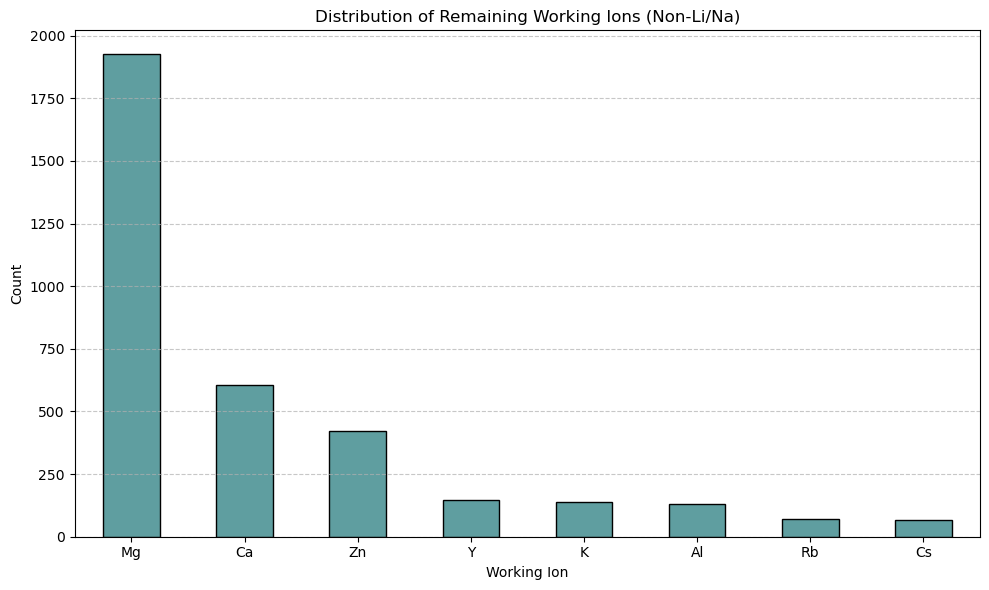

In [43]:
import matplotlib.pyplot as plt

# 1. Ensure working_ion is string (just in case)
df['working_ion'] = df['working_ion'].astype(str).str.strip()

# 2. Isolate "The Rest" 
# We filter out 'Li' and 'Na' because they are already handled in final_df
df_rest = df[~df['working_ion'].isin(['Li', 'Na'])].copy()

# 3. Calculate counts
ion_counts = df_rest['working_ion'].value_counts()

print(f"Total remaining rows: {len(df_rest)}")
print("Counts by ion:")
print(ion_counts)

# 4. Plot Bar Chart
plt.figure(figsize=(10, 6))
ion_counts.plot(kind='bar', color='cadetblue', edgecolor='black')

plt.title('Distribution of Remaining Working Ions (Non-Li/Na)')
plt.xlabel('Working Ion')
plt.ylabel('Count')
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [44]:
df_rest = df[~df['working_ion'].isin(['Li', 'Na', 'Cs', 'Y', 'Al', 'Rb']) & ~df['charge_id'].isin(final_df['charge_id'])].copy()
print(f"Original shape of df_rest: {df_rest.shape}")
li_min_idx = df_rest.groupby(['charge_id', 'Li_discharge_formula'])['Li_discharge_relaxed_energy_per_atom'].idxmin()
df_rest = df_rest.loc[li_min_idx].reset_index(drop=True)
print(f"New shape of df_rest: {df_rest.shape}")
df_merged = pd.concat([final_df,df_rest])
print(f"Size of final merged df: {df_merged.shape}")

Original shape of df_rest: (2406, 32)
New shape of df_rest: (1932, 32)
Size of final merged df: (4603, 32)


In [45]:
# Check for "Same ID, Same Formula" duplicates in the merged result
redundant_entries = df_merged[df_merged.duplicated(subset=['charge_id', 'Li_discharge_formula'], keep=False)]

print(f"Number of redundant rows (Same ID + Same Formula): {len(redundant_entries)}")

if len(redundant_entries) > 0:
    print("\nExample of redundant rows being kept now:")
    print(redundant_entries.sort_values('charge_id')[['working_ion','charge_id', 'Li_discharge_formula',
                                                      'Li_discharge_relaxed_energy_per_atom']].head(4))

Number of redundant rows (Same ID + Same Formula): 0


In [46]:
# # THIS SHOWS ROWS WHERE 'charge_id' is duplicated but 'Li_discharge_formula' is different due to the ratio of Li and host structure
# # Group by charge_id and find groups with multiple formulas
# conflicting = (
#     df.groupby('charge_id')['Li_discharge_formula']
#       .nunique()
#       .reset_index()
#       .query('Li_discharge_formula > 1')
# )

# # Now extract those rows from the original dataframe
# conflict_rows = df[df['charge_id'].isin(conflicting['charge_id'])]
# print(conflict_rows.sort_values(['charge_id', 'Li_discharge_formula']).iloc[3:8][['charge_id', 'Li_discharge_formula']])

In [47]:
# # THIS SHOWS ROWS WHERE 'charge_id' and 'Li_discharge_formula' are duplicated at the same time
# df_dupl = df[df.duplicated(subset=['charge_id','Li_discharge_formula'],keep=False)]
# df_dupl = df_dupl.sort_values(by='charge_id')
# df_dupl[['charge_id','Li_discharge_formula','Li_discharge_relaxed_energy_per_atom','Na_discharge_relaxed_energy_per_atom']]

In [48]:
# # Select the index of the lowest Li energy per group
# li_min_idx = df.groupby(['charge_id', 'Li_discharge_formula'])['Li_discharge_relaxed_energy_per_atom'].idxmin()

# # Keep only those rows
# df = df.loc[li_min_idx].reset_index(drop=True)
# df

In [49]:
df_final = df_merged[['charge_id','working_ion','charge_formula','charge_structure','charge_energy_per_atom',
                      'charge_relaxed_structure','charge_relaxed_energy_per_atom',
                      'Li_discharge_formula','Li_discharge_relaxed_structure','Li_discharge_relaxed_energy_per_atom',
                      'Na_discharge_formula','Na_discharge_relaxed_structure','Na_discharge_relaxed_energy_per_atom']]

df_final = df_final.reset_index(drop=True)

In [50]:
def calculate_binding_energy(df_row, working_ion_symbol, bulk_energy_per_atom):

    charged_struct = df_row['charge_relaxed_structure']
    charged_energy_pa = df_row['charge_relaxed_energy_per_atom']
    if working_ion_symbol == 'Li':
        discharged_struct = df_row['Li_discharge_relaxed_structure']
        discharged_energy_pa = df_row['Li_discharge_relaxed_energy_per_atom']
    elif working_ion_symbol == 'Na':
        discharged_struct = df_row['Na_discharge_relaxed_structure']
        discharged_energy_pa = df_row['Na_discharge_relaxed_energy_per_atom']
    else:
        return np.nan

    # Ensure all necessary components are present
    if not all(isinstance(s, Structure) for s in [charged_struct, discharged_struct]) or \
       pd.isna(charged_energy_pa) or pd.isna(discharged_energy_pa):
        return np.nan

    # Get compositions and remove working ion to find host compositions
    comp_charged = charged_struct.composition
    comp_discharged = discharged_struct.composition

    # Create host compositions by attempting to remove all potential working ions
    # to handle cases where the "charged" structure might still contain some working ions.
    host_elements_charged = [el for el in comp_charged.elements if el.symbol not in ['Li', 'Na']]
    host_comp_charged_dict = {el: comp_charged.get_atomic_fraction(el) * len(charged_struct)
                              for el in host_elements_charged}
    # Number of atoms in the host part of the charged structure
    num_host_atoms_charged = sum(host_comp_charged_dict.values())


    host_elements_discharged = [el for el in comp_discharged.elements if el.symbol not in ['Li', 'Na']]
    host_comp_discharged_dict = {el: comp_discharged.get_atomic_fraction(el) * len(discharged_struct)
                                 for el in host_elements_discharged}
    # Number of atoms in the host part of the discharged structure
    num_host_atoms_discharged = sum(host_comp_discharged_dict.values())

    # Scaling factor to make the amount of host material in charged_struct equal to that in discharged_struct
    # if num_host_atoms_charged == 0: print(charged_struct,working_ion_symbol)
    scaling_factor = num_host_atoms_discharged / num_host_atoms_charged

    # Calculate total energies
    e_charged_total_unscaled = charged_energy_pa * len(charged_struct)
    e_charged_total_scaled = e_charged_total_unscaled * scaling_factor

    e_discharged_total = discharged_energy_pa * len(discharged_struct)

    # Calculate number of working ions
    n_ion_charged_unscaled = comp_charged.get_el_amt_dict().get(working_ion_symbol, 0)
    n_ion_charged_scaled = n_ion_charged_unscaled * scaling_factor
    n_ion_discharged = comp_discharged.get_el_amt_dict().get(working_ion_symbol, 0)

    delta_n_ion = n_ion_discharged - n_ion_charged_scaled

    assert abs(len(discharged_struct) - scaling_factor*len(charged_struct) - delta_n_ion) < 0.00001, \
        f"Mismatch in atom counts: {len(discharged_struct)} - {scaling_factor*len(charged_struct)} - {delta_n_ion} != 0"

    if delta_n_ion <= 0: # No ions inserted, or ions removed
        return np.nan

    binding_energy = -(e_discharged_total - e_charged_total_scaled - (delta_n_ion * bulk_energy_per_atom)) / delta_n_ion
    return binding_energy

In [51]:
E_LI_BULK_PER_ATOM = -1.9032 - 3.04  # New value which are from UMA with reference of SHE
E_NA_BULK_PER_ATOM = -1.3093 - 2.71  # New value which are from UMA with reference of SHE

# E_LI_BULK_PER_ATOM = -1.9032  # New value which are from UMA
# E_NA_BULK_PER_ATOM = -1.3093  # New value which are from UMA

# E_LI_BULK_PER_ATOM = -2.377  # My old values which are wrong
# E_NA_BULK_PER_ATOM = -3.548  # My old values which are wrong

df_final['Li_voltage'] = df_final.apply(lambda row: calculate_binding_energy(row, 'Li', E_LI_BULK_PER_ATOM), axis=1)
df_final['Na_voltage'] = df_final.apply(lambda row: calculate_binding_energy(row, 'Na', E_NA_BULK_PER_ATOM), axis=1)

In [52]:
df_final.columns = ['host_mp_id', 'original_working_ion', 'host_formula', 'host_DFT_structure', 'host_DFT_energy_per_atom',
                    'host_structure','host_energy_per_atom',
                    'Li_formula', 'Li_structure', 'Li_energy_per_atom',
                    'Na_formula', 'Na_structure', 'Na_energy_per_atom',
                    'Li_voltage', 'Na_voltage']

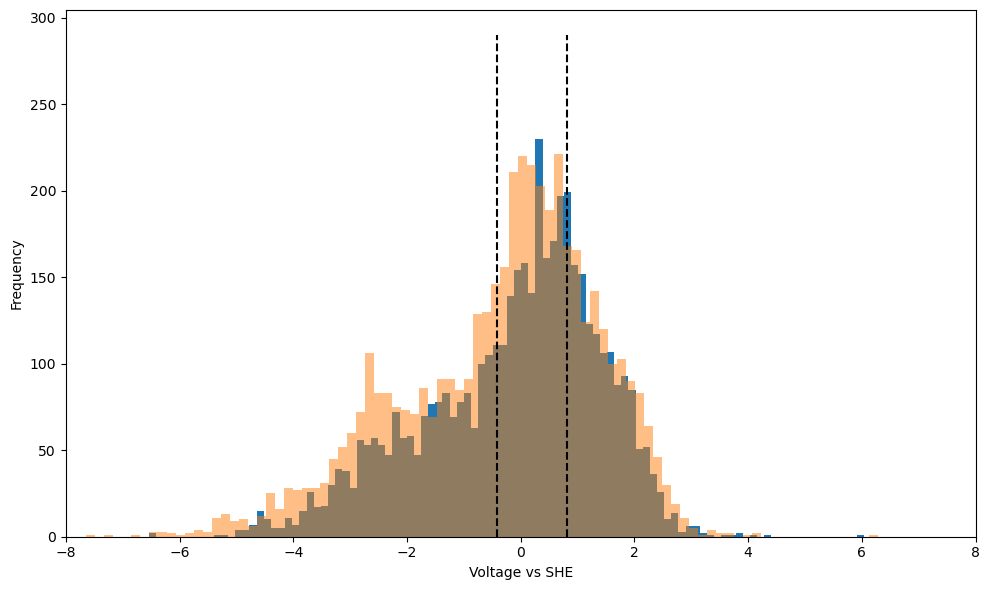

In [53]:
plt.figure(figsize=(10,6))
plt.hist(df_final['Li_voltage'],bins=100)
plt.hist(df_final['Na_voltage'],bins=100, alpha=0.5)
plt.plot([-0.4137,-0.4137], [0,290], "k--")
plt.plot([0.8163,0.8163], [0,290], "k--")
# plt.yscale('log')
plt.xlim(-8,8)
plt.xlabel("Voltage vs SHE")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig("na_voltage.png", dpi=300)
plt.show()

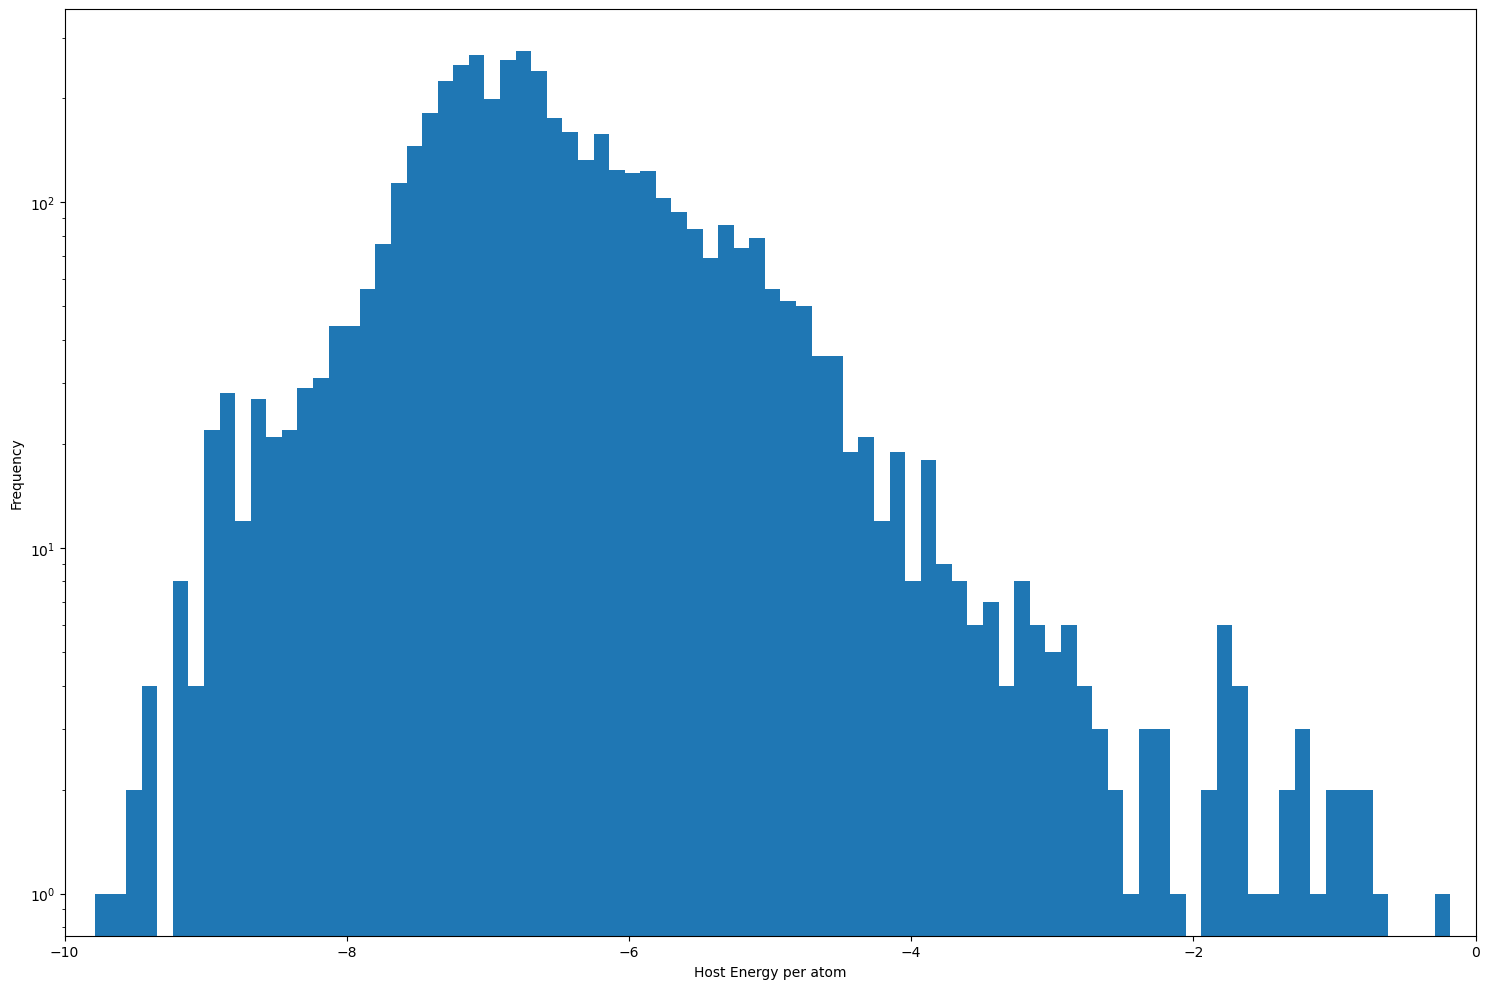

In [54]:
plt.figure(figsize=(15,10))
plt.hist(df_final['host_energy_per_atom'],bins=100)
plt.yscale('log')
plt.xlim(-10,0)
plt.xlabel("Host Energy per atom")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig("host_energy_per_atom.png", dpi=300)
plt.show()

In [56]:
# plt.figure(figsize=(10,10))
# plt.scatter(df_final['host_init_energy_per_atom'], df_final['host_energy_per_atom'])
# # plt.yscale('log')
# plt.xlabel("DFT energy per atom")
# plt.ylabel("UMA relaxed energy per atom")
# plt.tight_layout()
# plt.xlim(-15,0)
# plt.ylim(-15,0)
# # plt.savefig("uma_dft.png", dpi=300)
# plt.show()

In [57]:
df_final["Li_structure_n_atoms"] = df_final["Li_structure"].apply(lambda struct: len(struct))

In [58]:
df_final.to_hdf("final_dataset.h5", key='data', mode='w')

/tmp/ipykernel_2674333/3780783952.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['host_mp_id', 'original_working_ion', 'host_formula',
       'host_DFT_structure', 'host_structure', 'Li_formula', 'Li_structure',
       'Na_formula', 'Na_structure'],
      dtype='object')]

  df_final.to_hdf("final_dataset.h5", key='data', mode='w')
